In [22]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.datasets import GTSRB
from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os, random

# ── Configuration — edit these to match your setup ──────────────────────────
CFG = dict(
    model_path    = "/content/gtsrb_resnet18.pth",  # ← path to your trained model
    image_size    = 32,                # resize all images to this
    source_class  = 14,                # class we ATTACK  (14 = Stop sign)
    target_class  = 1,                 # desired wrong prediction (1 = 30 km/h)
    mask_type     = "rectangle",       # rectangle | circle | border | full
    mask_ratio    = 0.15,              # fraction of image covered by sticker
    epsilon       = 0.3,               # max L∞ perturbation per pixel
    alpha         = 0.01,              # Adam learning rate
    num_steps     = 200,               # optimisation iterations
    num_transforms= 10,                # physical transforms sampled per step
    lambda_tv     = 1e-4,              # smoothness regulariser weight
    lambda_lp     = 1e-3,              # L2 norm regulariser weight
    device        = "cuda" if torch.cuda.is_available() else "cpu",
    seed          = 42,
)

# Reproducibility
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
random.seed(CFG["seed"])

print("✓ Imports done")
print(f"  Device : {CFG['device']}")
print(f"  PyTorch: {torch.__version__}")

✓ Imports done
  Device : cuda
  PyTorch: 2.10.0+cu128


In [13]:
GTSRB_CLASSES = [
    "Speed limit (20km/h)", "Speed limit (30km/h)", "Speed limit (50km/h)",
    "Speed limit (60km/h)", "Speed limit (70km/h)", "Speed limit (80km/h)",
    "End of speed limit (80km/h)", "Speed limit (100km/h)", "Speed limit (120km/h)",
    "No passing", "No passing (>3.5t)", "Right-of-way at intersection",
    "Priority road", "Yield", "Stop", "No vehicles", "Vehicles >3.5t prohibited",
    "No entry", "General caution", "Dangerous curve left", "Dangerous curve right",
    "Double curve", "Bumpy road", "Slippery road", "Road narrows right",
    "Road work", "Traffic signals", "Pedestrians", "Children crossing",
    "Bicycles crossing", "Beware of ice/snow", "Wild animals crossing",
    "End of all restrictions", "Turn right ahead", "Turn left ahead", "Ahead only",
    "Go straight or right", "Go straight or left", "Keep right", "Keep left",
    "Roundabout mandatory", "End of no passing", "End of no passing (>3.5t)",
]

transform = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),   # → (C, H, W) float in [0, 1],
    T.Normalize(mean=[0.3337, 0.3064, 0.3171],
                std =[0.2672, 0.2564, 0.2629]),  # GTSRB statistics
])





# Download=True will auto-download if not present
dataset = GTSRB(root="./data", split="test", transform=transform, download=True)

# Filter to source class only
source_indices = [i for i, (_, label) in enumerate(dataset) if label == CFG["source_class"]]
print(f"\n✓ Dataset loaded: {len(dataset)} test images total")
print(f"  Source class {CFG['source_class']}: '{GTSRB_CLASSES[CFG['source_class']]}' → {len(source_indices)} images")
print(f"  Target class {CFG['target_class']}: '{GTSRB_CLASSES[CFG['target_class']]}'")


✓ Dataset loaded: 12630 test images total
  Source class 14: 'Stop' → 270 images
  Target class 1: 'Speed limit (30km/h)'


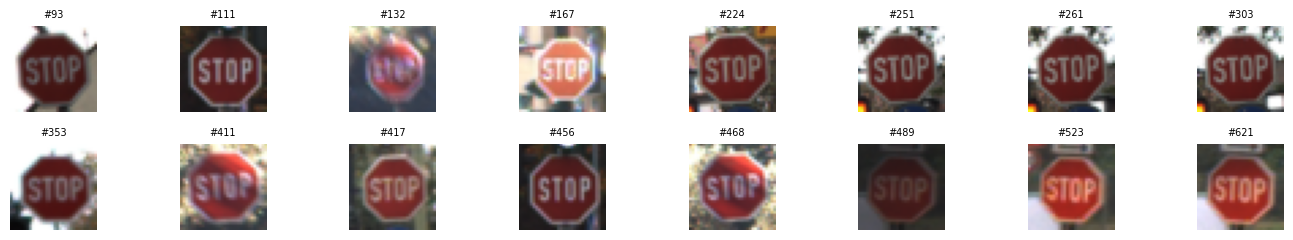

Showing 16 samples from class 14: 'Stop'


In [14]:
# Find the first correctly classified source image
MEAN = torch.tensor([0.3337, 0.3064, 0.3171]).view(3, 1, 1)
STD  = torch.tensor([0.2672, 0.2564, 0.2629]).view(3, 1, 1)

def denorm(t):
    """Undo normalization for display. t: (C,H,W) normalized tensor → [0,1]"""
    return (t * STD + MEAN).clamp(0, 1)

def show_images(imgs, titles=None, cols=8, figsize=(14, 3)):
    rows = max(1, len(imgs) // cols + int(len(imgs) % cols > 0))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < len(imgs):
            img = denorm(imgs[i]).permute(1, 2, 0).clamp(0, 1).numpy()
            ax.imshow(img)
            if titles: ax.set_title(titles[i], fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Pick 16 source class images to display
sample_idx = source_indices[:16]
sample_imgs = [dataset[i][0] for i in sample_idx]

show_images(
    sample_imgs,
    titles=[f"#{i}" for i in sample_idx],
    figsize=(14, 2.5)
)
print(f"Showing 16 samples from class {CFG['source_class']}: '{GTSRB_CLASSES[CFG['source_class']]}'")

In [15]:
# ── ★ EDIT THIS to match your model architecture ★ ───────────────────────────
#
# Pattern A: full model saved with torch.save(model, ...)
#model = torch.load(CFG["model_path"], map_location=CFG["device"])
#
# Pattern B: only state_dict saved — uncomment and fill in your architecture:
from torchvision.models import resnet18
model = resnet18(num_classes=43)
model.load_state_dict(torch.load(CFG["model_path"], map_location=CFG["device"]))
# ─────────────────────────────────────────────────────────────────────────────

model = model.to(CFG["device"]).eval()
print("✓ Model loaded and set to eval mode")

# Quick sanity check: classify the source images
correct = 0
preds = []
with torch.no_grad():
    for img in sample_imgs:
        logits = model(img.unsqueeze(0).to(CFG["device"]))
        pred = logits.argmax(1).item()
        preds.append(pred)
        correct += int(pred == CFG["source_class"])

print(f"\nBaseline accuracy on {len(sample_imgs)} source images: {correct}/{len(sample_imgs)} ({100*correct/len(sample_imgs):.0f}%)")
print(f"Predictions: {preds}  (expected all {CFG['source_class']})")

✓ Model loaded and set to eval mode

Baseline accuracy on 16 source images: 16/16 (100%)
Predictions: [14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14]  (expected all 14)


✓ Selected image index 93
  Model prediction: 14 → 'Stop' ✓


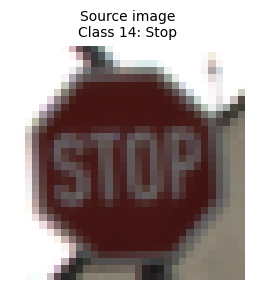


Image tensor shape: torch.Size([3, 32, 32])
Value range: [-0.938, 2.705]


In [16]:
x_orig = None
for idx in source_indices:
    img, label = dataset[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(CFG["device"])).argmax(1).item()
    if pred == CFG["source_class"]:
        x_orig = img   # (C, H, W) in [0, 1]
        print(f"✓ Selected image index {idx}")
        print(f"  Model prediction: {pred} → '{GTSRB_CLASSES[pred]}' ✓")
        break

if x_orig is None:
    raise RuntimeError("No correctly classified source image found. Check your model.")

# Display it
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(denorm(x_orig).permute(1, 2, 0).numpy())
ax.set_title(f"Source image\nClass {CFG['source_class']}: {GTSRB_CLASSES[CFG['source_class']]}", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"\nImage tensor shape: {x_orig.shape}")
print(f"Value range: [{x_orig.min():.3f}, {x_orig.max():.3f}]")

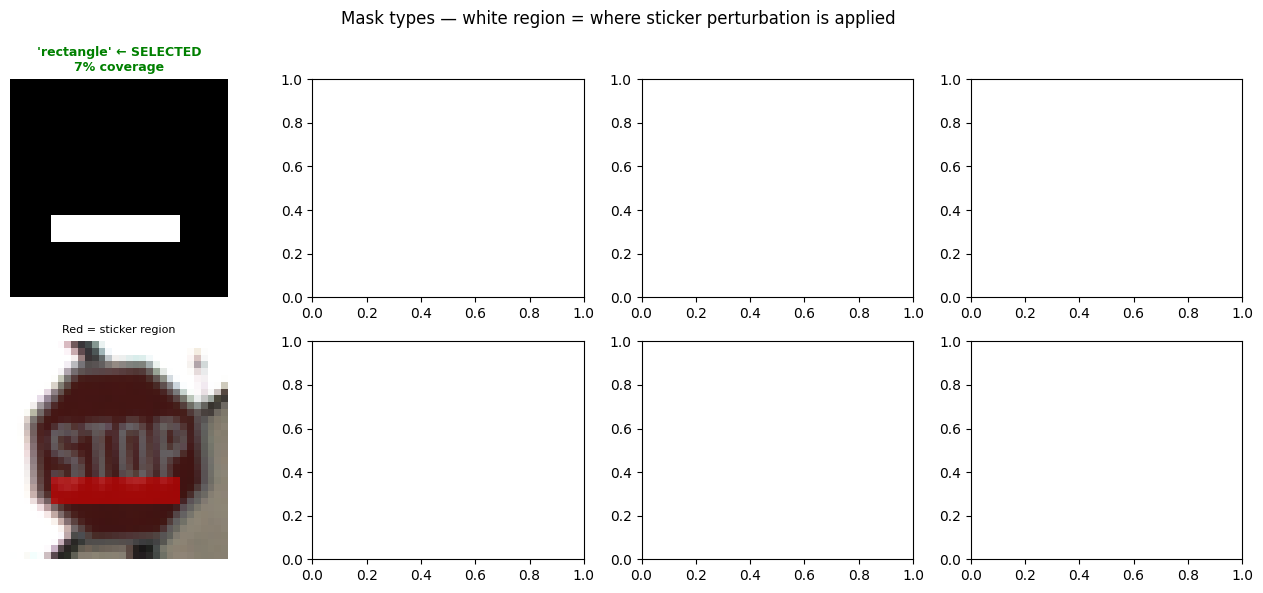


✓ Using mask type: 'rectangle' — 7% of pixels are perturbable


In [34]:
def build_mask(image_size, mask_type="rectangle", mask_ratio=0.15):
    """
    Returns a (1, H, W) binary float tensor.
    White pixels in the mask = where the sticker perturbation lives.
    """
    H = W = image_size
    mask = torch.zeros(1, H, W)

    if mask_type == "full":
        mask[:] = 1.0

    elif mask_type == "rectangle":
        h_p = int(H * mask_ratio)
        w_p = int(W * mask_ratio+15)
        r0, c0 = (H - h_p+12) // 2, (W - w_p)//2
        mask[:, r0:r0+h_p, c0:c0+w_p] = 1.0

    elif mask_type == "circle":
        radius = int(min(H, W) * mask_ratio / 2)
        cy, cx = H // 2, W // 2
        for r in range(H):
            for c in range(W):
                if (r-cy)**2 + (c-cx)**2 <= radius**2:
                    mask[0, r, c] = 1.0

    elif mask_type == "border":
        b = max(1, int(H * mask_ratio / 3))
        mask[:, :b, :] = 1.0
        mask[:, -b:, :] = 1.0
        mask[:, :, :b] = 1.0
        mask[:, :, -b:] = 1.0

    return mask


# Build all 4 mask types for comparison
mask_types = ["rectangle"]
masks = {mt: build_mask(CFG["image_size"], mt, CFG["mask_ratio"]) for mt in mask_types}

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
img_np = denorm(x_orig).permute(1, 2, 0).numpy()

for col, mt in enumerate(mask_types):
    m = masks[mt].squeeze(0).numpy()
    coverage = m.mean() * 100

    # Row 0: the mask itself
    axes[0, col].imshow(m, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"'{mt}'\n{coverage:.0f}% coverage", fontsize=9)
    axes[0, col].axis("off")

    # Row 1: mask overlaid on source image (red tint = perturbable)
    overlay = img_np.copy()
    overlay[m == 1, 0] = np.clip(overlay[m == 1, 0] * 0.5 + 0.5, 0, 1)  # red tint
    overlay[m == 1, 1] *= 0.4
    overlay[m == 1, 2] *= 0.4
    axes[1, col].imshow(overlay)
    axes[1, col].set_title("Red = sticker region", fontsize=8)
    axes[1, col].axis("off")

# Highlight the one we'll use
axes[0, mask_types.index(CFG["mask_type"])].set_title(
    f"'{CFG['mask_type']}' ← SELECTED\n{masks[CFG['mask_type']].mean()*100:.0f}% coverage",
    fontsize=9, color="green", fontweight="bold"
)

fig.suptitle("Mask types — white region = where sticker perturbation is applied", fontsize=12)
plt.tight_layout()
plt.show()

# Use the configured mask going forward
mask = masks[CFG["mask_type"]].to(CFG["device"])
print(f"\n✓ Using mask type: '{CFG['mask_type']}' — {mask.mean()*100:.0f}% of pixels are perturbable")

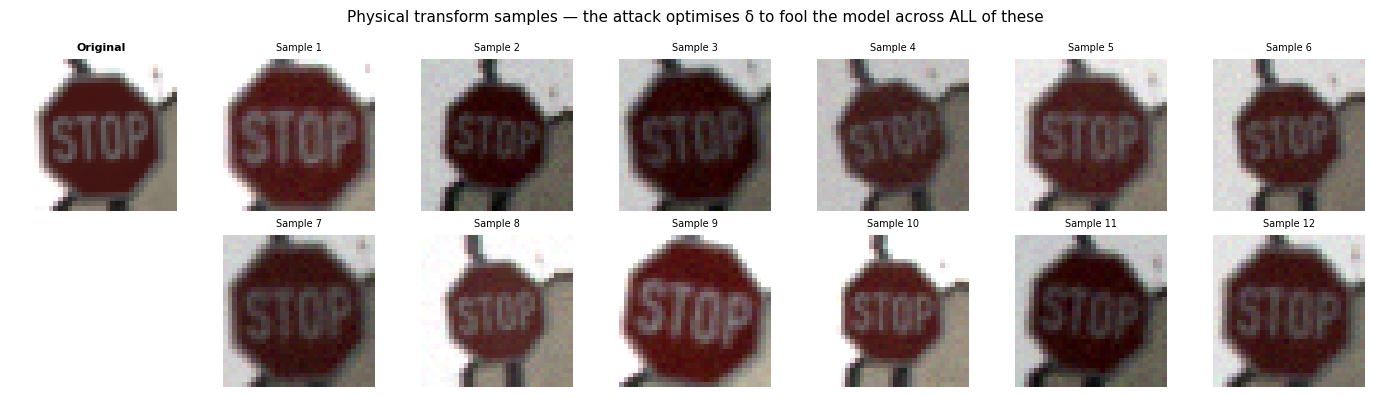

✓ Each optimisation step averages loss over 10 such random transforms


In [35]:
import torch.nn.functional as F

class PhysicalTransformSampler:
    """
    All ops are pure PyTorch — autograd graph stays intact so
    gradients flow all the way back to delta.
    """
    def __init__(
        self,
        angle_range      = (-15, 15),
        scale_range      = (0.8, 1.2),
        brightness_range = (0.7, 1.3),
        contrast_range   = (0.8, 1.2),
        noise_std        = 0.02,
    ):
        self.angle_range      = angle_range
        self.scale_range      = scale_range
        self.brightness_range = brightness_range
        self.contrast_range   = contrast_range
        self.noise_std        = noise_std

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        """x: (C,H,W) normalised tensor — returns transformed (C,H,W), graph intact."""

        x = x.unsqueeze(0)   # (1,C,H,W) for grid_sample

        # 1. Rotation + scale via affine grid (fully differentiable)
        angle = np.random.uniform(*self.angle_range)
        scale = np.random.uniform(*self.scale_range)
        rad   = torch.tensor(angle * np.pi / 180.0, dtype=torch.float32)
        cos_a, sin_a = torch.cos(rad), torch.sin(rad)

        # 2×3 affine matrix: rotation + scale combined
        theta = torch.tensor([[
            [cos_a / scale, -sin_a / scale, 0.0],
            [sin_a / scale,  cos_a / scale, 0.0],
        ]], dtype=torch.float32, device=x.device)

        grid = F.affine_grid(theta, x.shape, align_corners=False)
        x    = F.grid_sample(x, grid, align_corners=False, padding_mode="border")

        x = x.squeeze(0)   # back to (C,H,W)

        # 2. Brightness (multiplicative — differentiable)
        brightness = np.random.uniform(*self.brightness_range)
        x = x * brightness

        # 3. Contrast (differentiable)
        contrast = np.random.uniform(*self.contrast_range)
        mean = x.mean(dim=(1, 2), keepdim=True)
        x    = (x - mean) * contrast + mean

        # 4. Gaussian noise (differentiable — adds to graph but gradient passes through)
        x = x + torch.randn_like(x) * self.noise_std

        return x   # stays normalised — no re-normalize needed

sampler = PhysicalTransformSampler()

# --- Visualise 12 random transforms of our chosen image ---
n_show = 12
transformed = [sampler(denorm(x_orig)) for _ in range(n_show)]

fig, axes = plt.subplots(2, 7, figsize=(14, 4))
# First cell = original
axes[0, 0].imshow(denorm(x_orig).permute(1, 2, 0).numpy())
axes[0, 0].set_title("Original", fontsize=8, fontweight="bold")
axes[0, 0].axis("off")
axes[1, 0].axis("off")

for i, t in enumerate(transformed):
    r, c = divmod(i, 6)
    ax = axes[r, c + 1]
    ax.imshow(t.permute(1, 2, 0).numpy())
    ax.set_title(f"Sample {i+1}", fontsize=7)
    ax.axis("off")

fig.suptitle(
    "Physical transform samples — the attack optimises δ to fool the model across ALL of these",
    fontsize=11
)
plt.tight_layout()
plt.show()

print(f"✓ Each optimisation step averages loss over {CFG['num_transforms']} such random transforms")

In [36]:
x = x_orig.to(CFG["device"])          # clean image on device
target = torch.tensor([CFG["target_class"]], device=CFG["device"])

# ── δ: the adversarial perturbation we will optimise ─────────────────────────
# Initialise with small random noise INSIDE the mask only.
# Starting from zero also works but small noise gives Adam a better starting signal.
delta = (torch.rand_like(x) * 2 - 1) * 0.01 * mask
delta = delta.detach().requires_grad_(True)

optimizer = torch.optim.Adam([delta], lr=CFG["alpha"])
criterion = nn.CrossEntropyLoss()

# ── Helper functions ──────────────────────────────────────────────────────────


def apply_perturbation(x, delta):
    return x + mask * delta

def tv_loss(delta):
    """Total-variation: penalises abrupt pixel-to-pixel changes in δ."""
    diff_h = (delta[:, 1:, :] - delta[:, :-1, :]).abs().mean()
    diff_w = (delta[:, :, 1:] - delta[:, :, :-1]).abs().mean()
    return diff_h + diff_w


def project(delta):
    return delta.clamp(-CFG["epsilon"], CFG["epsilon"]) * mask

print("✓ Optimisation components ready")
print(f"  δ shape : {delta.shape}")
print(f"  ε (L∞)  : {CFG['epsilon']}")
print(f"  Steps   : {CFG['num_steps']}")
print(f"  Transforms/step: {CFG['num_transforms']}")
print(f"  λ_tv    : {CFG['lambda_tv']}   λ_lp : {CFG['lambda_lp']}")

✓ Optimisation components ready
  δ shape : torch.Size([3, 32, 32])
  ε (L∞)  : 0.3
  Steps   : 200
  Transforms/step: 10
  λ_tv    : 0.0001   λ_lp : 0.001


In [37]:
# ── Cell 8 — Optimisation Setup ──────────────────────────────────────────────
MEAN = torch.tensor([0.3337, 0.3064, 0.3171]).view(3,1,1).to(CFG["device"])
STD  = torch.tensor([0.2672, 0.2564, 0.2629]).view(3,1,1).to(CFG["device"])

x = x_orig.to(CFG["device"])
target = torch.tensor([CFG["target_class"]], device=CFG["device"])

# δ lives in NORMALISED space — same space as x
delta = (torch.rand_like(x) * 2 - 1) * 0.01 * mask
delta = delta.detach().requires_grad_(True)

optimizer = torch.optim.Adam([delta], lr=CFG["alpha"])
criterion = nn.CrossEntropyLoss()

# ── Helpers ───────────────────────────────────────────────────────────────────

def apply_perturbation(x, delta):
    # NO clamp here — x is normalised, values live in ~[-1, 3]
    # Clamping to [0,1] would destroy most of the image
    return x + mask * delta

def tv_loss(delta):
    # delta is (C, H, W) — index along H and W dims
    diff_h = (delta[:, 1:, :] - delta[:, :-1, :]).abs().mean()
    diff_w = (delta[:, :, 1:] - delta[:, :, :-1]).abs().mean()
    return diff_h + diff_w

def project(delta):
    # Only constrain delta itself — NOT the full image
    return delta.clamp(-CFG["epsilon"], CFG["epsilon"]) * mask

print("✓ Cell 8 ready")
print(f"  x range     : [{x.min():.3f}, {x.max():.3f}]  (normalised — expected ~[-1, 3])")
print(f"  delta range : [{delta.min():.4f}, {delta.max():.4f}]  (tiny init noise)")
print(f"  ε budget    : ±{CFG['epsilon']}")

✓ Cell 8 ready
  x range     : [-0.938, 2.705]  (normalised — expected ~[-1, 3])
  delta range : [-0.0099, 0.0098]  (tiny init noise)
  ε budget    : ±0.3


In [38]:
loss_history      = []   # total loss each step
cls_loss_history  = []   # classification part only
pred_history      = []   # model's prediction on x̂ each step
conf_history      = []   # confidence on target class

print(f"Starting RP2 optimisation for {CFG['num_steps']} steps …\n")
print(f"{'Step':>6}  {'Total Loss':>11}  {'CE Loss':>9}  {'TV Loss':>8}  {'Pred':>6}  {'Conf(target)':>13}")
print("-" * 65)

for step in range(CFG["num_steps"]):
    optimizer.zero_grad()

    # ── (A) Expectation over physical transforms ──────────────────────────
    total_cls_loss = torch.tensor(0.0, device=CFG["device"])
    for _ in range(CFG["num_transforms"]):
        x_adv = apply_perturbation(x, delta)          # (C, H, W)
        x_t   = sampler(x_adv).to(CFG["device"])      # physical transform
        logits = model(x_t.unsqueeze(0))               # (1, num_classes)
        total_cls_loss += criterion(logits, target)

    cls_loss = total_cls_loss / CFG["num_transforms"]

    # ── (B) Regularisation ────────────────────────────────────────────────
    loss_tv = tv_loss(mask * delta)
    loss_lp = (mask * delta).norm(p=2)
    loss    = cls_loss + CFG["lambda_tv"] * loss_tv + CFG["lambda_lp"] * loss_lp

    # ── (C) Gradient step ────────────────────────────────────────────────
    loss.backward()
    optimizer.step()

    # ── (D) Project δ back onto feasible set ─────────────────────────────
    with torch.no_grad():
        delta.data = project(delta.data)

    # ── Logging ──────────────────────────────────────────────────────────
    loss_history.append(loss.item())
    cls_loss_history.append(cls_loss.item())

    with torch.no_grad():
        x_adv_clean = apply_perturbation(x, delta)
        logits_eval = model(x_adv_clean.unsqueeze(0))
        probs       = torch.softmax(logits_eval, dim=1)[0]
        pred        = probs.argmax().item()
        conf_target = probs[CFG["target_class"]].item()
        pred_history.append(pred)
        conf_history.append(conf_target)

    if (step + 1) % 20 == 0 or step == 0:
        status = "✓" if pred == CFG["target_class"] else " "
        print(f"{step+1:>6}  {loss.item():>11.4f}  {cls_loss.item():>9.4f}  "
              f"{loss_tv.item():>8.5f}  {pred:>5}{status}  {conf_target:>12.2%}")

print("\n✓ Optimisation complete!")

Starting RP2 optimisation for 200 steps …

  Step   Total Loss    CE Loss   TV Loss    Pred   Conf(target)
-----------------------------------------------------------------
     1       2.0612     2.0611   0.00114     14          5.11%
    20       1.0170     1.0152   0.01295     14         43.11%
    40       0.2292     0.2262   0.02208      1✓        88.68%
    60       0.4937     0.4903   0.02527      1✓        93.26%
    80       0.2559     0.2523   0.02677      1✓        94.51%
   100       0.1828     0.1791   0.02767      1✓        94.95%
   120       0.1194     0.1156   0.02847      1✓        96.00%
   140       0.2868     0.2830   0.02919      1✓        96.08%
   160       0.4083     0.4043   0.02941      1✓        96.53%
   180       0.3239     0.3199   0.03000      1✓        96.73%
   200       0.2481     0.2440   0.03033      1✓        96.90%

✓ Optimisation complete!


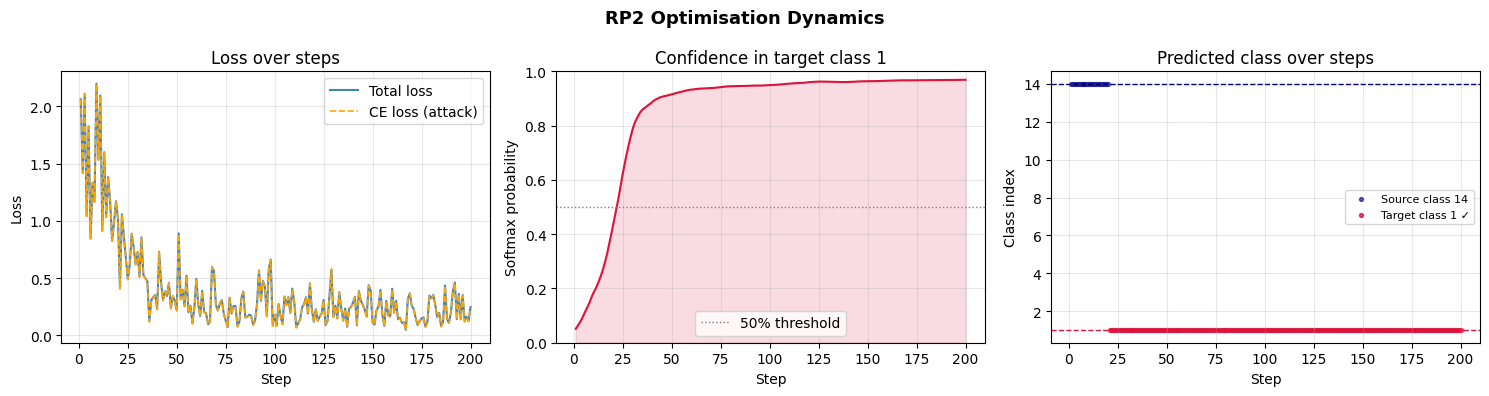


Summary:
  First successful step : 21
  Final prediction      : 1 (Speed limit (30km/h))
  Final conf (target)   : 96.90%
  Attack success        : ✓ YES


In [39]:
steps = np.arange(1, CFG["num_steps"] + 1)
success_mask = np.array(pred_history) == CFG["target_class"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("RP2 Optimisation Dynamics", fontsize=13, fontweight="bold")

# Plot 1: Total loss
axes[0].plot(steps, loss_history, color="steelblue", lw=1.5, label="Total loss")
axes[0].plot(steps, cls_loss_history, color="orange", lw=1.2, ls="--", label="CE loss (attack)")
axes[0].set_title("Loss over steps")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot 2: Confidence in target class
axes[1].plot(steps, conf_history, color="crimson", lw=1.5)
axes[1].axhline(0.5, color="gray", ls=":", lw=1, label="50% threshold")
# Shade region where attack succeeds
axes[1].fill_between(steps, conf_history, alpha=0.15, color="crimson")
axes[1].set_title(f"Confidence in target class {CFG['target_class']}")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Softmax probability")
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

# Plot 3: Predicted class over time
axes[2].scatter(steps[~success_mask], np.array(pred_history)[~success_mask],
                c="navy", s=8, label=f"Source class {CFG['source_class']}", alpha=0.6)
axes[2].scatter(steps[success_mask], np.array(pred_history)[success_mask],
                c="crimson", s=8, label=f"Target class {CFG['target_class']} ✓", alpha=0.8)
axes[2].axhline(CFG["target_class"], color="crimson", ls="--", lw=1)
axes[2].axhline(CFG["source_class"], color="navy", ls="--", lw=1)
axes[2].set_title("Predicted class over steps")
axes[2].set_xlabel("Step"); axes[2].set_ylabel("Class index")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
first_success = next((i+1 for i, p in enumerate(pred_history) if p == CFG["target_class"]), None)
final_success = pred_history[-1] == CFG["target_class"]

print(f"\nSummary:")
print(f"  First successful step : {first_success}")
print(f"  Final prediction      : {pred_history[-1]} ({GTSRB_CLASSES[pred_history[-1]]})")
print(f"  Final conf (target)   : {conf_history[-1]:.2%}")
print(f"  Attack success        : {'✓ YES' if final_success else '✗ NO — try more steps or larger ε'}")

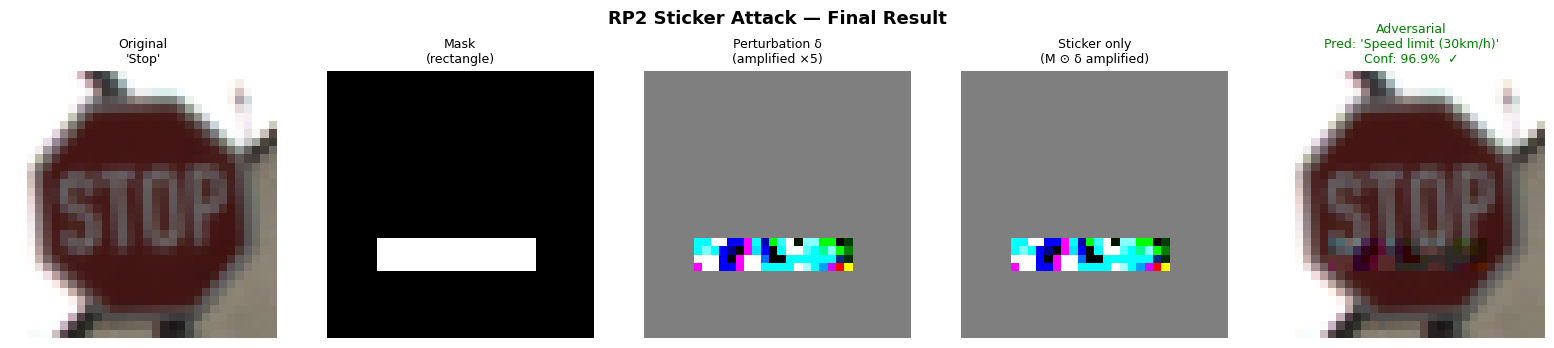


✓ Saved to rp2_result.png


In [40]:
with torch.no_grad():
    x_adv   = apply_perturbation(x, delta).cpu()   # final adversarial image
    delta_np = delta.cpu()                          # raw perturbation

# Get final prediction
with torch.no_grad():
    logits = model(x_adv.unsqueeze(0).to(CFG["device"]))
    probs  = torch.softmax(logits, dim=1)[0].cpu()
    pred   = probs.argmax().item()
    conf   = probs[pred].item()

def t2np(t):
    return t.cpu().permute(1, 2, 0).clamp(0, 1).numpy()

orig_np  = t2np(denorm(x_orig.cuda()))
adv_np   = t2np(denorm(x_adv.cuda()))
pert_amp = t2np((delta_np * 5 + 0.5).clamp(0, 1))        # amplified ×5
sticker  = t2np((mask.cpu() * delta_np * 5 + 0.5).clamp(0, 1))  # masked only

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
fig.suptitle("RP2 Sticker Attack — Final Result", fontsize=13, fontweight="bold")

axes[0].imshow(orig_np)
axes[0].set_title(f"Original\n'{GTSRB_CLASSES[CFG['source_class']]}'", fontsize=9)

axes[1].imshow(mask.cpu().squeeze(0).numpy(), cmap="gray")
axes[1].set_title(f"Mask\n({CFG['mask_type']})", fontsize=9)

axes[2].imshow(pert_amp)
axes[2].set_title("Perturbation δ\n(amplified ×5)", fontsize=9)

axes[3].imshow(sticker)
axes[3].set_title("Sticker only\n(M ⊙ δ amplified)", fontsize=9)

success = pred == CFG["target_class"]
axes[4].imshow(adv_np)
axes[4].set_title(
    f"Adversarial\nPred: '{GTSRB_CLASSES[pred]}'\nConf: {conf:.1%}  {'✓' if success else '✗'}",
    fontsize=9,
    color="green" if success else "red"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.savefig("rp2_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Saved to rp2_result.png")

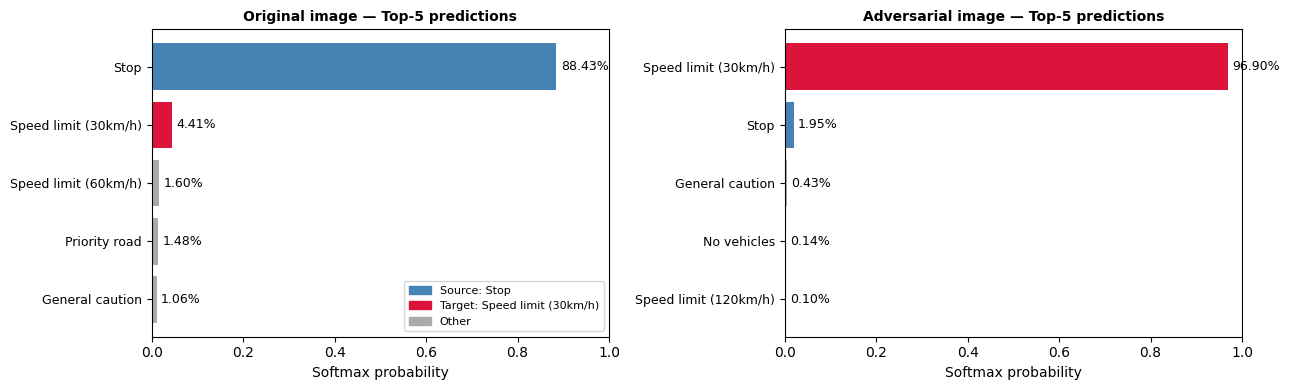

In [41]:
with torch.no_grad():
    probs_orig = torch.softmax(model(x_orig.unsqueeze(0).to(CFG["device"])), dim=1)[0].cpu()
    probs_adv  = torch.softmax(model(x_adv.unsqueeze(0).to(CFG["device"])),  dim=1)[0].cpu()

top5_orig  = probs_orig.topk(5)
top5_adv   = probs_adv.topk(5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, probs_top, title in [
    (axes[0], top5_orig, "Original image — Top-5 predictions"),
    (axes[1], top5_adv,  "Adversarial image — Top-5 predictions"),
]:
    labels = [f"{GTSRB_CLASSES[i.item()]}" for i in probs_top.indices]
    values = probs_top.values.numpy()
    colors = []
    for i in probs_top.indices:
        if i.item() == CFG["source_class"]: colors.append("steelblue")
        elif i.item() == CFG["target_class"]: colors.append("crimson")
        else: colors.append("#aaaaaa")

    bars = ax.barh(range(5), values, color=colors)
    ax.set_yticks(range(5))
    ax.set_yticklabels([f"{l[:30]}" for l in labels], fontsize=9)
    ax.set_xlabel("Softmax probability")
    ax.set_xlim(0, 1)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.invert_yaxis()
    for bar, v in zip(bars, values):
        ax.text(v + 0.01, bar.get_y() + bar.get_height()/2, f"{v:.2%}",
                va="center", fontsize=9)

# Legend
import matplotlib.patches as mpatches
axes[0].legend(handles=[
    mpatches.Patch(color="steelblue", label=f"Source: {GTSRB_CLASSES[CFG['source_class']]}"),
    mpatches.Patch(color="crimson",   label=f"Target: {GTSRB_CLASSES[CFG['target_class']]}"),
    mpatches.Patch(color="#aaaaaa",   label="Other"),
], fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

In [43]:
# ── How well does our patch generalise? ──────────────────────────────────────

test_indices = [i for i in source_indices if i != 93][:20]  # 20 unseen stop signs

# ── Test 1: transfer the SAME delta to new images (no re-optimisation) ───────
transfer_success = 0
with torch.no_grad():
    for idx in test_indices:
        img, _ = dataset[idx]
        img    = img.to(CFG["device"])
        x_adv  = img + mask * delta          # apply saved delta directly
        pred   = model(x_adv.unsqueeze(0)).argmax(1).item()
        transfer_success += int(pred == CFG["target_class"])

transfer_asr = transfer_success / len(test_indices)
print(f"Patch transfer ASR (same δ, new images): {transfer_success}/{len(test_indices)} = {transfer_asr:.0%}")

# ── Test 2: re-optimise delta fresh for each image ───────────────────────────
reopt_success = 0
for idx in test_indices:
    img, _ = dataset[idx]
    img    = img.to(CFG["device"])

    d = (torch.rand_like(img) * 2 - 1) * 0.01 * mask
    d = d.detach().requires_grad_(True)
    opt = torch.optim.Adam([d], lr=CFG["alpha"])

    for step in range(CFG["num_steps"]):
        opt.zero_grad()
        loss = torch.tensor(0.0, device=CFG["device"])
        for _ in range(CFG["num_transforms"]):
            x_adv  = img + mask * d
            x_t    = sampler(x_adv)
            loss  += criterion(model(x_t.unsqueeze(0)), target)
        loss = loss / CFG["num_transforms"]
        loss += CFG["lambda_tv"] * tv_loss(mask * d)
        loss += CFG["lambda_lp"] * (mask * d).norm(p=2)
        loss.backward()
        opt.step()
        with torch.no_grad():
            d.data = d.data.clamp(-CFG["epsilon"], CFG["epsilon"]) * mask

    with torch.no_grad():
        pred = model((img + mask * d).unsqueeze(0)).argmax(1).item()
    reopt_success += int(pred == CFG["target_class"])
    print(f"  Image {idx}: {'✓' if pred == CFG['target_class'] else '✗'} pred={pred}")

reopt_asr = reopt_success / len(test_indices)
print(f"\nPer-image optimisation ASR: {reopt_success}/{len(test_indices)} = {reopt_asr:.0%}")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*45}")
print(f"  Same patch transfer  : {transfer_asr:.0%}")
print(f"  Per-image reoptimise : {reopt_asr:.0%}")
print(f"{'='*45}")
print("\nIf transfer ASR << reopt ASR, the patch is image-specific.")
print("If transfer ASR ≈ reopt ASR, the patch generalises well.")

Patch transfer ASR (same δ, new images): 3/20 = 15%
  Image 111: ✗ pred=14
  Image 132: ✗ pred=14
  Image 167: ✓ pred=1
  Image 224: ✓ pred=1
  Image 251: ✗ pred=14
  Image 261: ✗ pred=14
  Image 303: ✗ pred=14
  Image 353: ✗ pred=14
  Image 411: ✗ pred=14
  Image 417: ✗ pred=14
  Image 456: ✗ pred=14
  Image 468: ✗ pred=14
  Image 489: ✓ pred=1
  Image 523: ✗ pred=14
  Image 621: ✗ pred=14
  Image 666: ✓ pred=1
  Image 681: ✓ pred=1
  Image 686: ✗ pred=14
  Image 726: ✓ pred=1
  Image 732: ✗ pred=14

Per-image optimisation ASR: 6/20 = 30%

  Same patch transfer  : 15%
  Per-image reoptimise : 30%

If transfer ASR << reopt ASR, the patch is image-specific.
If transfer ASR ≈ reopt ASR, the patch generalises well.


✓ Imports done
  Device : cuda
  PyTorch: 2.10.0+cu128

✓ Dataset loaded: 12630 test images total
  Source class 14: 'Stop' → 270 images
  Target class 1: 'Speed limit (30km/h)'

✓ Model loaded and set to eval mode

✓ 1 correctly-classified stop-sign images collected (out of 270 total stop-sign images)


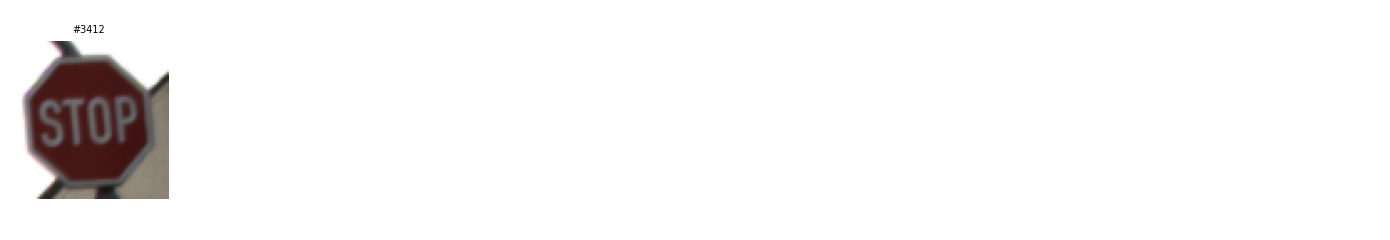

Showing up to 16 of the 1 source images

✓ Mask built: type='rectangle', coverage=5.3% of pixels
✓ Physical transform sampler ready

✓ Optimisation setup complete
  δ shape           : torch.Size([3, 64, 64])
  ε (L∞)            : 0.3
  Steps             : 500
  Transforms/step   : 10
  Images/step       : 8  ← sampled from 1 total
  λ_tv / λ_lp       : 0.0001 / 0.001

Starting RP2 optimisation for 500 steps …
  Step   Total Loss    CE Loss   TV Loss  Batch ASR   MeanConf
-----------------------------------------------------------------
     1       3.9645     3.9644   0.00075        0%      2.53%
    20       3.5140     3.5114   0.00697        0%      6.97%
    40       2.1503     2.1458   0.01235        0%     23.71%
    60       2.0529     2.0476   0.01518      100%     41.45%
    80       1.9297     1.9239   0.01687      100%     50.80%
   100       1.5710     1.5649   0.01774      100%     56.58%
   120       2.2258     2.2195   0.01837      100%     61.35%
   140       2.1579    

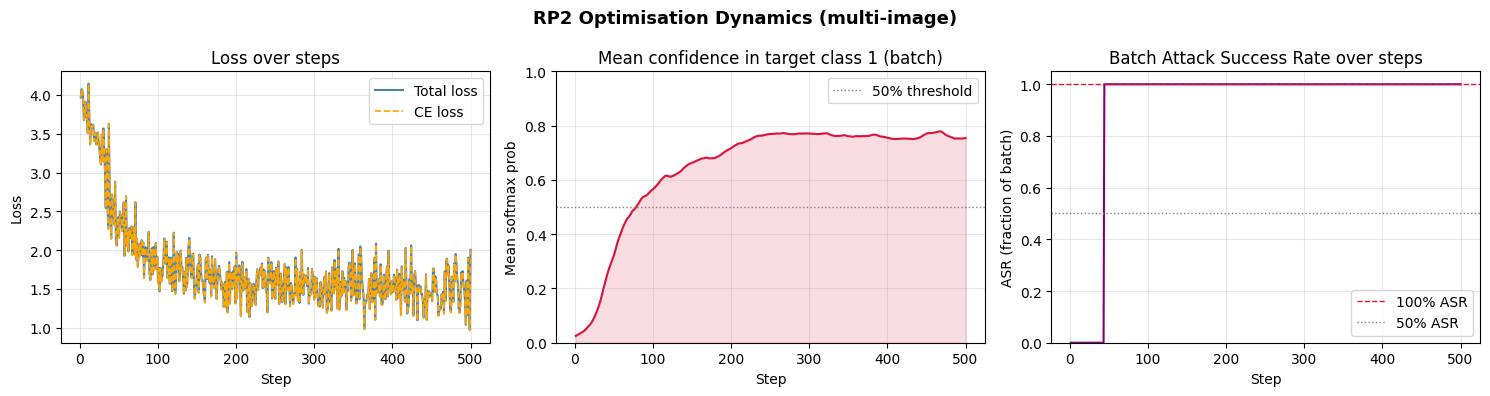

✓ Saved training dynamics → rp2_training_dynamics.png


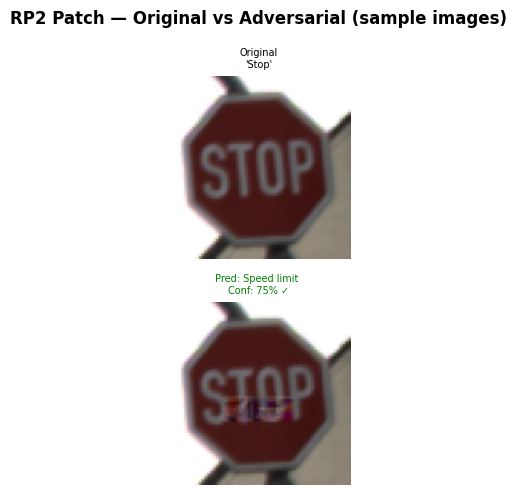

✓ Saved patch examples → rp2_patch_examples.png

Evaluating patch on all 1 source images …

  Total source images evaluated : 1
  Successful attacks            : 1
  Attack Success Rate (ASR)     : 100.0%
  Mean confidence on target     : 75.5%


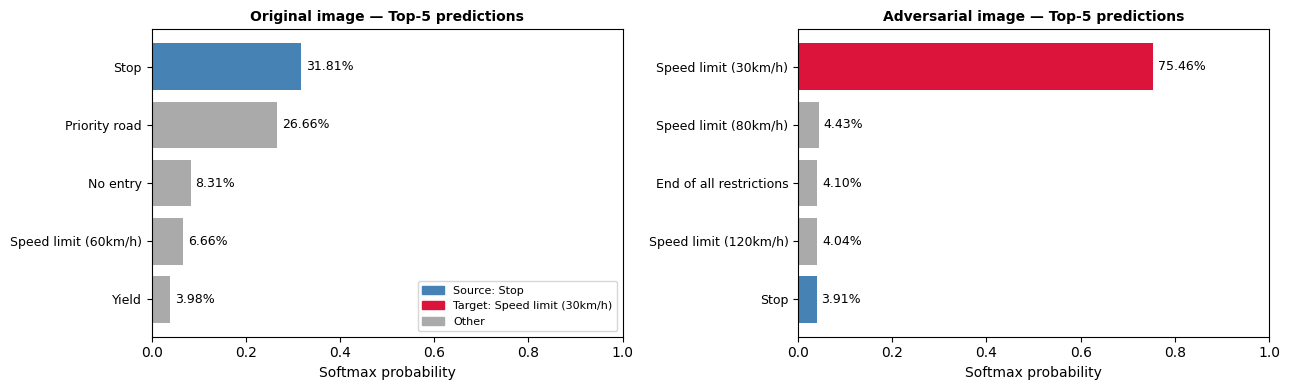

✓ Saved top-5 chart → rp2_top5.png

Running per-image re-optimisation baseline …
  Image   1: ✓  pred=Speed limit (30km/h)

  Patch transfer ASR (all 1 images) : 100.0%
  Per-image re-opt ASR (first 20)      : 100.0%
  ✓ Transfer ASR ≈ per-image ASR → patch generalises well across images.

Done. Outputs: rp2_training_dynamics.png  rp2_patch_examples.png  rp2_top5.png


In [58]:
"""
RP2 — Robust Physical Perturbation Attack on Stop Signs
========================================================
Corrected implementation: patch is optimised across the FULL distribution
of source-class images each step, as described in Eykholt et al. (2018).

Key fix over original code:
  - All correctly-classified stop-sign images are loaded upfront
  - Each optimisation step randomly samples `batch_size` of them
  - A single delta is forced to fool the model across that distribution
  - This produces a physically robust patch, not an image-specific one

NPS (non-printability score) loss is intentionally omitted.
"""

# ── 0. Imports ────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from torchvision.datasets import GTSRB
from torchvision.models import resnet18
from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from PIL import Image
import os, random

print("✓ Imports done")

# ── 1. Configuration ──────────────────────────────────────────────────────────
CFG = dict(
    model_path     = "/content/gtsrb_resnet18.pth",  # ← path to your trained model
    image_size     = 64,               # resize all images to this
    source_class   = 14,               # class we ATTACK  (14 = Stop sign)
    target_class   = 1,                # desired wrong prediction (1 = 30 km/h)
    mask_type      = "rectangle",      # rectangle | circle | border | full
    mask_ratio     = 0.15,             # fraction of image covered by sticker
    epsilon        = 0.3,              # max L∞ perturbation per pixel
    alpha          = 0.01,             # Adam learning rate
    num_steps      = 500,              # optimisation iterations
    num_transforms = 10,               # physical transforms sampled per step
    batch_size     = 8,                # ← NEW: source images sampled per step
    lambda_tv      = 1e-4,             # smoothness regulariser weight
    lambda_lp      = 1e-3,             # L2 norm regulariser weight
    device         = "cuda" if torch.cuda.is_available() else "cpu",
    seed           = 42,
)

# Reproducibility
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
random.seed(CFG["seed"])

print(f"  Device : {CFG['device']}")
print(f"  PyTorch: {torch.__version__}")

# ── 2. Class names ────────────────────────────────────────────────────────────
GTSRB_CLASSES = [
    "Speed limit (20km/h)", "Speed limit (30km/h)", "Speed limit (50km/h)",
    "Speed limit (60km/h)", "Speed limit (70km/h)", "Speed limit (80km/h)",
    "End of speed limit (80km/h)", "Speed limit (100km/h)", "Speed limit (120km/h)",
    "No passing", "No passing (>3.5t)", "Right-of-way at intersection",
    "Priority road", "Yield", "Stop", "No vehicles", "Vehicles >3.5t prohibited",
    "No entry", "General caution", "Dangerous curve left", "Dangerous curve right",
    "Double curve", "Bumpy road", "Slippery road", "Road narrows right",
    "Road work", "Traffic signals", "Pedestrians", "Children crossing",
    "Bicycles crossing", "Beware of ice/snow", "Wild animals crossing",
    "End of all restrictions", "Turn right ahead", "Turn left ahead", "Ahead only",
    "Go straight or right", "Go straight or left", "Keep right", "Keep left",
    "Roundabout mandatory", "End of no passing", "End of no passing (>3.5t)",
]

# ── 3. Dataset & transforms ───────────────────────────────────────────────────
MEAN = torch.tensor([0.3337, 0.3064, 0.3171])
STD  = torch.tensor([0.2672, 0.2564, 0.2629])

transform = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),
    T.Normalize(mean=MEAN.tolist(), std=STD.tolist()),
])

dataset = GTSRB(root="./data", split="test", transform=transform, download=True)

source_indices = [i for i, (_, label) in enumerate(dataset) if label == CFG["source_class"]]
print(f"\n✓ Dataset loaded: {len(dataset)} test images total")
print(f"  Source class {CFG['source_class']}: '{GTSRB_CLASSES[CFG['source_class']]}'"
      f" → {len(source_indices)} images")
print(f"  Target class {CFG['target_class']}: '{GTSRB_CLASSES[CFG['target_class']]}'")

# ── 4. Helpers ────────────────────────────────────────────────────────────────
MEAN_d = MEAN.view(3, 1, 1)
STD_d  = STD.view(3, 1, 1)

def denorm(t):
    """Undo GTSRB normalisation for display. t: (C,H,W) → [0,1]"""
    return (t.cpu() * STD_d + MEAN_d).clamp(0, 1)

def show_images(imgs, titles=None, cols=8, figsize=(14, 3)):
    rows = max(1, len(imgs) // cols + int(len(imgs) % cols > 0))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < len(imgs):
            ax.imshow(denorm(imgs[i]).permute(1, 2, 0).numpy())
            if titles:
                ax.set_title(titles[i], fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# ── 5. Load model ─────────────────────────────────────────────────────────────
model = resnet18(num_classes=43)
model.load_state_dict(torch.load(CFG["model_path"], map_location=CFG["device"]))
model = model.to(CFG["device"]).eval()
print("\n✓ Model loaded and set to eval mode")

# ── 6. Collect ALL correctly-classified source images ─────────────────────────
#
# FIX: instead of picking only the first correct image, we gather every
# correctly-classified stop sign.  The optimiser will sample from this pool
# each step, so the single delta must fool ALL of them — exactly as in RP2.
#
print("\nCollecting correctly-classified source images …")
source_imgs = []
source_img_indices = []

with torch.no_grad():
    for idx in source_indices:
        img, label = dataset[idx]
        pred = model(img.unsqueeze(0).to(CFG["device"])).argmax(1).item()
        if pred == CFG["source_class"]:
            source_imgs.append(img)          # keep on CPU; move to device during training
            source_img_indices.append(idx)

print(f"✓ {len(source_imgs)} correctly-classified stop-sign images collected "
      f"(out of {len(source_indices)} total stop-sign images)")

if len(source_imgs) == 0:
    raise RuntimeError("No correctly classified source images found. Check your model.")

# Quick preview
show_images(
    source_imgs[:16],
    titles=[f"#{i}" for i in source_img_indices[:16]],
    figsize=(14, 2.5)
)
print(f"Showing up to 16 of the {len(source_imgs)} source images")

# ── 7. Mask builder ───────────────────────────────────────────────────────────
def build_mask(image_size, mask_type="rectangle", mask_ratio=0.15):
    """Returns a (1, H, W) binary float tensor (1 = perturbable)."""
    H = W = image_size
    mask = torch.zeros(1, H, W)

    if mask_type == "full":
        mask[:] = 1.0

    elif mask_type == "rectangle":
        h_p = int(H * mask_ratio)
        w_p = int(W * mask_ratio + 15)
        r0  = (H - h_p + 12) // 2
        c0  = (W - w_p) // 2
        mask[:, r0:r0 + h_p, c0:c0 + w_p] = 1.0

    elif mask_type == "circle":
        radius = int(min(H, W) * mask_ratio / 2)
        cy, cx = H // 2, W // 2
        for r in range(H):
            for c in range(W):
                if (r - cy) ** 2 + (c - cx) ** 2 <= radius ** 2:
                    mask[0, r, c] = 1.0

    elif mask_type == "border":
        b = max(1, int(H * mask_ratio / 3))
        mask[:, :b, :]  = 1.0
        mask[:, -b:, :] = 1.0
        mask[:, :, :b]  = 1.0
        mask[:, :, -b:] = 1.0

    return mask

mask = build_mask(CFG["image_size"], CFG["mask_type"], CFG["mask_ratio"]).to(CFG["device"])
print(f"\n✓ Mask built: type='{CFG['mask_type']}', "
      f"coverage={mask.mean()*100:.1f}% of pixels")

# ── 8. Physical transform sampler ─────────────────────────────────────────────
class PhysicalTransformSampler:
    """
    Differentiable simulation of physical-world viewing conditions.
    All ops preserve the autograd graph so gradients flow back to delta.
    """
    def __init__(
        self,
        angle_range      = (-15, 15),
        scale_range      = (0.8, 1.2),
        brightness_range = (0.7, 1.3),
        contrast_range   = (0.8, 1.2),
        noise_std        = 0.02,
    ):
        self.angle_range      = angle_range
        self.scale_range      = scale_range
        self.brightness_range = brightness_range
        self.contrast_range   = contrast_range
        self.noise_std        = noise_std

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        """x: (C,H,W) normalised tensor → transformed (C,H,W), graph intact."""
        x = x.unsqueeze(0)   # → (1,C,H,W)

        # 1. Rotation + scale (differentiable affine grid)
        angle = np.random.uniform(*self.angle_range)
        scale = np.random.uniform(*self.scale_range)
        rad   = torch.tensor(angle * np.pi / 180.0, dtype=torch.float32)
        cos_a, sin_a = torch.cos(rad), torch.sin(rad)
        theta = torch.tensor([[
            [cos_a / scale, -sin_a / scale, 0.0],
            [sin_a / scale,  cos_a / scale, 0.0],
        ]], dtype=torch.float32, device=x.device)
        grid = F.affine_grid(theta, x.shape, align_corners=False)
        x    = F.grid_sample(x, grid, align_corners=False, padding_mode="border")
        x    = x.squeeze(0)   # → (C,H,W)

        # 2. Brightness
        x = x * np.random.uniform(*self.brightness_range)

        # 3. Contrast
        contrast = np.random.uniform(*self.contrast_range)
        mean     = x.mean(dim=(1, 2), keepdim=True)
        x        = (x - mean) * contrast + mean

        # 4. Gaussian noise
        x = x + torch.randn_like(x) * self.noise_std

        return x

sampler = PhysicalTransformSampler()
print("✓ Physical transform sampler ready")

# ── 9. Optimisation helpers ───────────────────────────────────────────────────
def apply_perturbation(x, delta):
    """Add masked delta to image (in normalised space — no clamping)."""
    return x + mask * delta

def tv_loss(d):
    """Total-variation smoothness penalty on d (C,H,W)."""
    diff_h = (d[:, 1:, :] - d[:, :-1, :]).abs().mean()
    diff_w = (d[:, :, 1:] - d[:, :, :-1]).abs().mean()
    return diff_h + diff_w

def project(d):
    """Project delta back into the L∞ ball and re-apply mask."""
    return d.clamp(-CFG["epsilon"], CFG["epsilon"]) * mask

# ── 10. Initialise delta ──────────────────────────────────────────────────────
# A SINGLE delta is shared across all source images.
# Initialise with tiny noise inside the mask.
delta = (torch.rand(3, CFG["image_size"], CFG["image_size"],
                    device=CFG["device"]) * 2 - 1) * 0.01 * mask
delta = delta.detach().requires_grad_(True)

optimizer = torch.optim.AdamW([delta], lr=CFG["alpha"])
criterion = nn.CrossEntropyLoss()
target    = torch.tensor([CFG["target_class"]], device=CFG["device"])

print(f"\n✓ Optimisation setup complete")
print(f"  δ shape           : {delta.shape}")
print(f"  ε (L∞)            : {CFG['epsilon']}")
print(f"  Steps             : {CFG['num_steps']}")
print(f"  Transforms/step   : {CFG['num_transforms']}")
print(f"  Images/step       : {CFG['batch_size']}  ← sampled from {len(source_imgs)} total")
print(f"  λ_tv / λ_lp       : {CFG['lambda_tv']} / {CFG['lambda_lp']}")

# ── 11. Multi-image RP2 optimisation loop ─────────────────────────────────────
#
# CORE FIX: every step we randomly sample `batch_size` images from the full
# pool of correctly-classified stop signs.  The EoT loop (num_transforms) then
# runs for EACH of those images.  Gradients accumulate across both loops before
# the Adam step, forcing the single delta to be universally adversarial.
#
loss_history     = []
cls_loss_history = []
pred_history     = []   # majority prediction across the batch
conf_history     = []   # mean confidence on target across the batch

print(f"\nStarting RP2 optimisation for {CFG['num_steps']} steps …")
print(f"{'Step':>6}  {'Total Loss':>11}  {'CE Loss':>9}  {'TV Loss':>8}"
      f"  {'Batch ASR':>9}  {'MeanConf':>9}")
print("-" * 65)

for step in range(CFG["num_steps"]):
    optimizer.zero_grad()

    # Sample a mini-batch of source images for this step
    batch = random.sample(source_imgs, k=min(CFG["batch_size"], len(source_imgs)))

    total_cls_loss = torch.tensor(0.0, device=CFG["device"])
    step_preds     = []
    step_confs     = []

    for x in batch:
        x = x.to(CFG["device"])

        # EoT: average loss over random physical transforms for this image
        img_cls_loss = torch.tensor(0.0, device=CFG["device"])
        for _ in range(CFG["num_transforms"]):
            x_adv  = apply_perturbation(x, delta)
            x_t    = sampler(x_adv).to(CFG["device"])
            logits = model(x_t.unsqueeze(0))
            img_cls_loss += criterion(logits, target)

        total_cls_loss += img_cls_loss / CFG["num_transforms"]

        # Logging: eval on clean adversarial (no transform) for this image
        with torch.no_grad():
            x_adv_clean = apply_perturbation(x, delta)
            probs = torch.softmax(model(x_adv_clean.unsqueeze(0)), dim=1)[0]
            step_preds.append(probs.argmax().item())
            step_confs.append(probs[CFG["target_class"]].item())

    # Average classification loss over the batch
    cls_loss = total_cls_loss / len(batch)

    # Regularisation (image-independent — applied once)
    loss_tv = tv_loss(mask * delta)
    loss_lp = (mask * delta).norm(p=2)
    loss    = cls_loss + CFG["lambda_tv"] * loss_tv + CFG["lambda_lp"] * loss_lp

    loss.backward()
    optimizer.step()

    with torch.no_grad():
        delta.data = project(delta.data)

    # Logging
    loss_history.append(loss.item())
    cls_loss_history.append(cls_loss.item())
    batch_asr  = sum(p == CFG["target_class"] for p in step_preds) / len(step_preds)
    mean_conf  = float(np.mean(step_confs))
    pred_history.append(batch_asr)
    conf_history.append(mean_conf)

    if (step + 1) % 20 == 0 or step == 0:
        print(f"{step+1:>6}  {loss.item():>11.4f}  {cls_loss.item():>9.4f}  "
              f"{loss_tv.item():>8.5f}  {batch_asr:>8.0%}  {mean_conf:>9.2%}")

print("\n✓ Optimisation complete!")

# ── 12. Training dynamics plot ────────────────────────────────────────────────
steps = np.arange(1, CFG["num_steps"] + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("RP2 Optimisation Dynamics (multi-image)", fontsize=13, fontweight="bold")

axes[0].plot(steps, loss_history,     color="steelblue", lw=1.5, label="Total loss")
axes[0].plot(steps, cls_loss_history, color="orange",    lw=1.2, ls="--", label="CE loss")
axes[0].set_title("Loss over steps")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(steps, conf_history, color="crimson", lw=1.5)
axes[1].axhline(0.5, color="gray", ls=":", lw=1, label="50% threshold")
axes[1].fill_between(steps, conf_history, alpha=0.15, color="crimson")
axes[1].set_title(f"Mean confidence in target class {CFG['target_class']} (batch)")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Mean softmax prob")
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(steps, pred_history, color="purple", lw=1.5)
axes[2].axhline(1.0, color="crimson", ls="--", lw=1, label="100% ASR")
axes[2].axhline(0.5, color="gray",    ls=":",  lw=1, label="50% ASR")
axes[2].set_title("Batch Attack Success Rate over steps")
axes[2].set_xlabel("Step"); axes[2].set_ylabel("ASR (fraction of batch)")
axes[2].set_ylim(0, 1.05); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("rp2_training_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved training dynamics → rp2_training_dynamics.png")

# ── 13. Visualise the patch on a few example images ──────────────────────────
n_show = min(6, len(source_imgs))
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.5, 5), squeeze=False)
fig.suptitle("RP2 Patch — Original vs Adversarial (sample images)", fontsize=12, fontweight="bold")

with torch.no_grad():
    for col, x in enumerate(source_imgs[:n_show]):
        x      = x.to(CFG["device"])
        x_adv  = apply_perturbation(x, delta)
        pred   = model(x_adv.unsqueeze(0)).argmax(1).item()
        conf   = torch.softmax(model(x_adv.unsqueeze(0)), dim=1)[0, CFG["target_class"]].item()
        success = pred == CFG["target_class"]

        axes[0, col].imshow(denorm(x).permute(1, 2, 0).numpy())
        axes[0, col].set_title(f"Original\n'{GTSRB_CLASSES[CFG['source_class']]}'", fontsize=7)
        axes[0, col].axis("off")

        axes[1, col].imshow(denorm(x_adv).permute(1, 2, 0).numpy())
        axes[1, col].set_title(
            f"Pred: {GTSRB_CLASSES[pred][:12]}\nConf: {conf:.0%} {'✓' if success else '✗'}",
            fontsize=7,
            color="green" if success else "red"
        )
        axes[1, col].axis("off")

plt.tight_layout()
plt.savefig("rp2_patch_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved patch examples → rp2_patch_examples.png")
# ── 14. Full evaluation — all source images ───────────────────────────────────
#
# This is the definitive test: apply the single trained delta to every
# correctly-classified stop sign without re-optimisation.
#
print(f"\nEvaluating patch on all {len(source_imgs)} source images …")

full_success  = 0
all_preds     = []
all_confs     = []

with torch.no_grad():
    for x in source_imgs:
        x      = x.to(CFG["device"])
        x_adv  = apply_perturbation(x, delta)
        probs  = torch.softmax(model(x_adv.unsqueeze(0)), dim=1)[0]
        pred   = probs.argmax().item()
        conf   = probs[CFG["target_class"]].item()
        all_preds.append(pred)
        all_confs.append(conf)
        full_success += int(pred == CFG["target_class"])

full_asr = full_success / len(source_imgs)

print(f"\n{'='*50}")
print(f"  Total source images evaluated : {len(source_imgs)}")
print(f"  Successful attacks            : {full_success}")
print(f"  Attack Success Rate (ASR)     : {full_asr:.1%}")
print(f"  Mean confidence on target     : {np.mean(all_confs):.1%}")
print(f"{'='*50}")

# ── 15. Top-5 prediction bar charts (first image) ────────────────────────────
x_first = source_imgs[0].to(CFG["device"])
with torch.no_grad():
    probs_orig = torch.softmax(model(x_first.unsqueeze(0)), dim=1)[0].cpu()
    x_adv_first = apply_perturbation(x_first, delta)
    probs_adv  = torch.softmax(model(x_adv_first.unsqueeze(0)), dim=1)[0].cpu()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, probs_top, title in [
    (axes[0], probs_orig.topk(5), "Original image — Top-5 predictions"),
    (axes[1], probs_adv.topk(5),  "Adversarial image — Top-5 predictions"),
]:
    labels = [GTSRB_CLASSES[i.item()] for i in probs_top.indices]
    values = probs_top.values.numpy()
    colors = []
    for i in probs_top.indices:
        if   i.item() == CFG["source_class"]: colors.append("steelblue")
        elif i.item() == CFG["target_class"]: colors.append("crimson")
        else:                                  colors.append("#aaaaaa")

    bars = ax.barh(range(5), values, color=colors)
    ax.set_yticks(range(5))
    ax.set_yticklabels([l[:30] for l in labels], fontsize=9)
    ax.set_xlabel("Softmax probability")
    ax.set_xlim(0, 1)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.invert_yaxis()
    for bar, v in zip(bars, values):
        ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{v:.2%}", va="center", fontsize=9)

axes[0].legend(handles=[
    mpatches.Patch(color="steelblue", label=f"Source: {GTSRB_CLASSES[CFG['source_class']]}"),
    mpatches.Patch(color="crimson",   label=f"Target: {GTSRB_CLASSES[CFG['target_class']]}"),
    mpatches.Patch(color="#aaaaaa",   label="Other"),
], fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("rp2_top5.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved top-5 chart → rp2_top5.png")

# ── 16. Transfer vs per-image re-optimisation comparison ─────────────────────
#
# Split source_imgs into a held-out transfer test set (not used in training
# if you want a clean split — here we just use all of them for demonstration).
#
test_imgs = source_imgs   # in a real experiment, hold out a separate test set

# Test 1: direct transfer of the trained delta
transfer_success = 0
with torch.no_grad():
    for x in test_imgs:
        x     = x.to(CFG["device"])
        x_adv = apply_perturbation(x, delta)
        pred  = model(x_adv.unsqueeze(0)).argmax(1).item()
        transfer_success += int(pred == CFG["target_class"])
transfer_asr = transfer_success / len(test_imgs)

# Test 2: per-image re-optimisation from scratch (upper-bound baseline)
reopt_success = 0
print("\nRunning per-image re-optimisation baseline …")
for idx, x in enumerate(test_imgs[:20]):   # cap at 20 to keep runtime reasonable
    x = x.to(CFG["device"])

    d   = (torch.rand_like(x) * 2 - 1) * 0.01 * mask
    d   = d.detach().requires_grad_(True)
    opt = torch.optim.Adam([d], lr=CFG["alpha"])

    for _ in range(CFG["num_steps"]):
        opt.zero_grad()
        loss = torch.tensor(0.0, device=CFG["device"])
        for _ in range(CFG["num_transforms"]):
            x_adv  = apply_perturbation(x, d)
            x_t    = sampler(x_adv).to(CFG["device"])
            loss  += criterion(model(x_t.unsqueeze(0)), target)
        loss = loss / CFG["num_transforms"]
        loss += CFG["lambda_tv"] * tv_loss(mask * d)
        loss += CFG["lambda_lp"] * (mask * d).norm(p=2)
        loss.backward()
        opt.step()
        with torch.no_grad():
            d.data = project(d.data)

    with torch.no_grad():
        pred = model(apply_perturbation(x, d).unsqueeze(0)).argmax(1).item()
    reopt_success += int(pred == CFG["target_class"])
    print(f"  Image {idx+1:>3}: {'✓' if pred == CFG['target_class'] else '✗'}  pred={GTSRB_CLASSES[pred]}")

reopt_asr = reopt_success / min(20, len(test_imgs))

print(f"\n{'='*50}")
print(f"  Patch transfer ASR (all {len(test_imgs)} images) : {transfer_asr:.1%}")
print(f"  Per-image re-opt ASR (first 20)      : {reopt_asr:.1%}")
print(f"{'='*50}")
if transfer_asr >= reopt_asr * 0.8:
    print("  ✓ Transfer ASR ≈ per-image ASR → patch generalises well across images.")
else:
    print("  ✗ Transfer ASR << per-image ASR → patch is still somewhat image-specific.")
    print("    Try: more steps, larger batch_size, or wider transform ranges.")

print("\nDone. Outputs: rp2_training_dynamics.png  rp2_patch_examples.png  rp2_top5.png")